In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [7]:
import pandas as pd

In [32]:
import pandas as pd

customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

In [34]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [33]:
orders.shape

(99441, 8)

In [36]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [35]:
customers.head()
customers.shape
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [37]:
payments.head()
payments.shape
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [38]:
items.head()
items.shape
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [39]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [40]:
orders.duplicated().sum()

np.int64(0)

In [41]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [42]:
customers.duplicated().sum()

np.int64(0)

In [43]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [44]:
payments.duplicated().sum()

np.int64(0)

In [45]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [46]:
items.duplicated().sum()

np.int64(0)

In [47]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [48]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [49]:
order_payments = orders.merge(payments, on='order_id', how='left')
master = order_payments.merge(customers, on='customer_id', how='left')
master.head()
master.shape

(103887, 16)

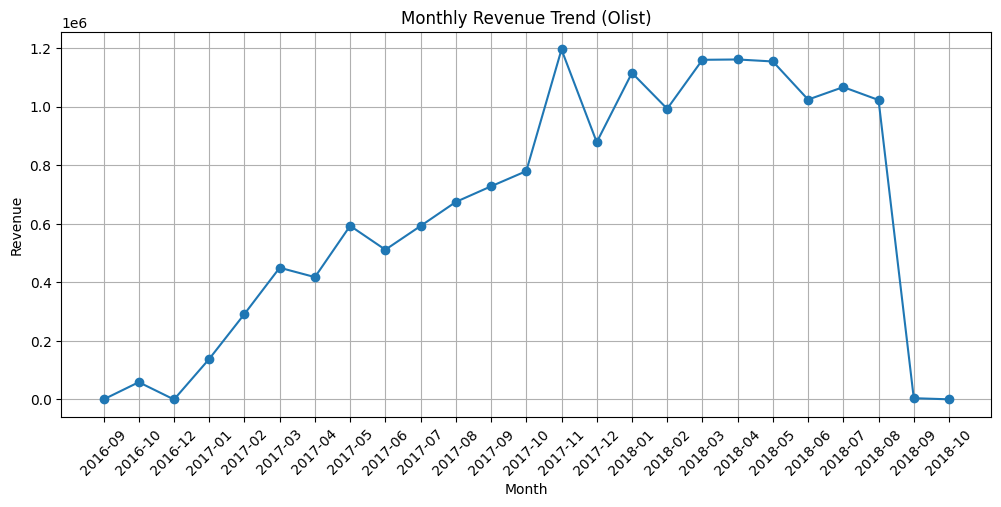

In [50]:
master['month'] = master['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = master.groupby('month')['payment_value'].sum()

monthly_revenue
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype(str)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['month'], monthly_revenue['payment_value'], marker='o')

plt.title("Monthly Revenue Trend (Olist)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [51]:
monthly_revenue = master.groupby(
    master['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

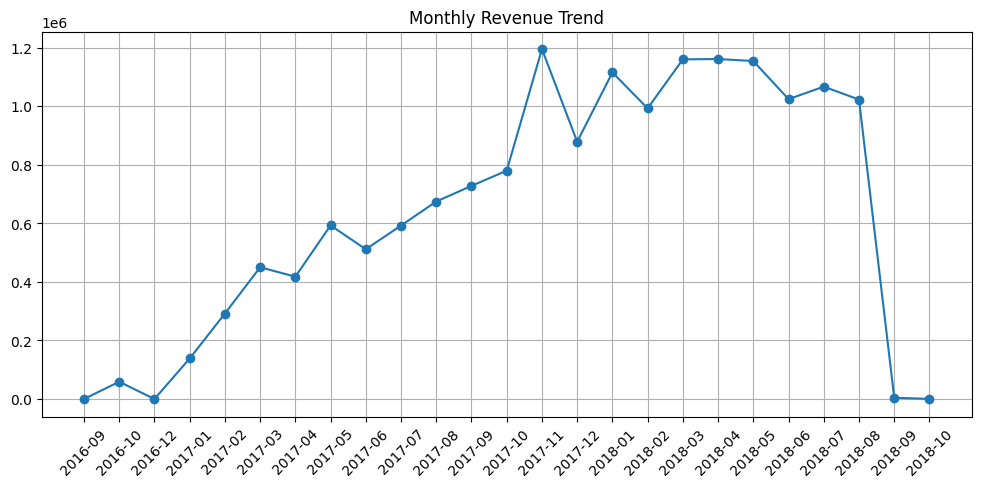

In [52]:
monthly_revenue.sort_values('revenue', ascending=False).head(5)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o')

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [65]:
base_path = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'


In [67]:
import pandas as pd

products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')

In [68]:
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

In [69]:
profit_df = items.copy()
profit_df['profit'] = profit_df['price'] - profit_df['freight_value']

In [71]:
profit_df = profit_df.merge(products, on='product_id', how='left')

In [72]:
'product_category_name' in profit_df.columns

False

In [74]:
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')

profit_df = items.merge(products, on='product_id', how='left')

profit_df['profit'] = profit_df['price'] - profit_df['freight_value']

In [75]:
'product_category_name' in profit_df.columns

True

In [76]:
profit_by_category = profit_df.groupby('product_category_name')['profit'].sum().sort_values(ascending=False)

profit_by_category.head(10)

product_category_name
relogios_presentes        1104469.75
beleza_saude              1076114.61
cama_mesa_banho            832295.64
esporte_lazer              819441.46
informatica_acessorios     764636.24
moveis_decoracao           557013.19
cool_stuff                 551251.75
automotivo                 500055.90
utilidades_domesticas      486099.55
brinquedos                 406520.65
Name: profit, dtype: float64

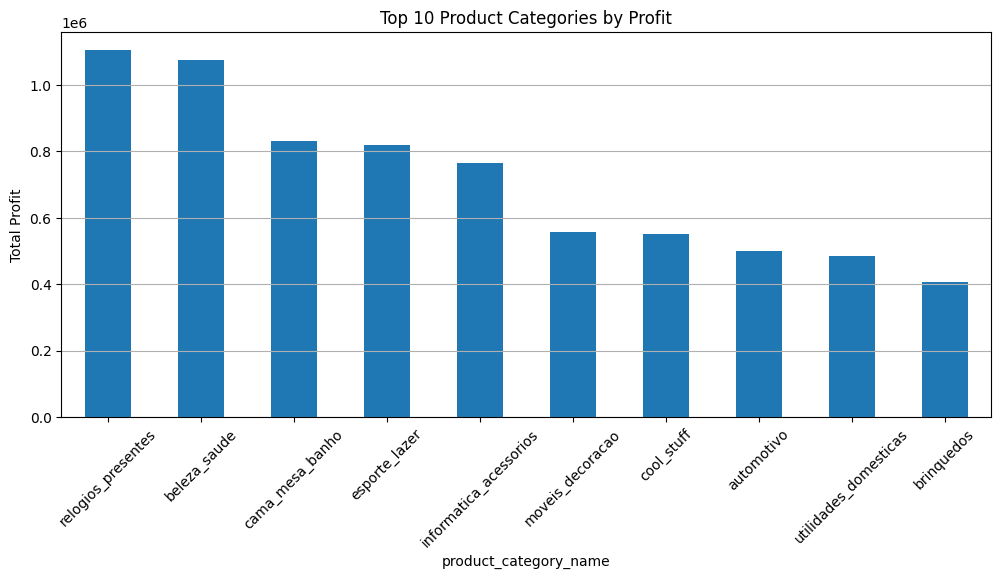

In [77]:
import matplotlib.pyplot as plt

top10 = profit_by_category.head(10)

plt.figure(figsize=(12,5))
top10.plot(kind='bar')

plt.title("Top 10 Product Categories by Profit")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [78]:
profit_by_seller = profit_df.groupby('seller_id')['profit'].sum().sort_values(ascending=False)

profit_by_seller.head(10)

seller_id
53243585a1d6dc2643021fd1853d8905    209695.42
4869f7a5dfa277a7dca6462dcf3b52b2    209304.56
fa1c13f2614d7b5c4749cbc52fecda94    183999.33
7e93a43ef30c4f03f38b393420bc753a    170109.69
4a3ca9315b744ce9f8e9374361493884    165405.88
7c67e1448b00f6e969d365cea6b010ab    136311.34
da8622b14eb17ae2831f4ac5b9dab84a    135280.82
7a67c85e85bb2ce8582c35f2203ad736    120842.68
46dc3b2cc0980fb8ec44634e21d2718e    116312.69
955fee9216a65b617aa5c0531780ce60    109740.72
Name: profit, dtype: float64

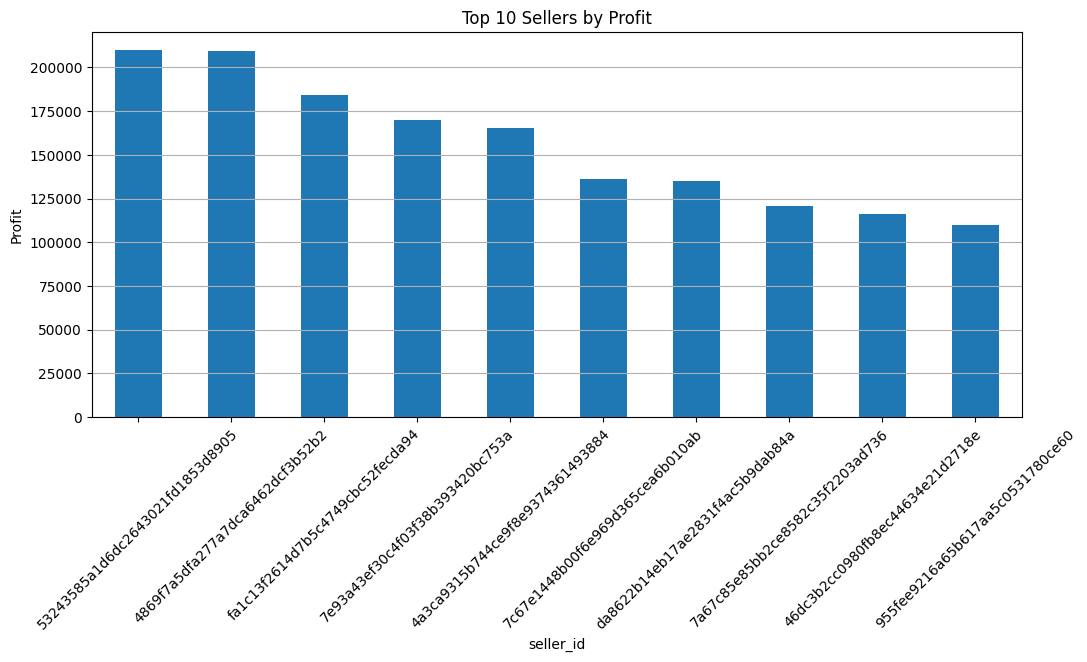

In [79]:
import matplotlib.pyplot as plt

top_sellers = profit_by_seller.head(10)

plt.figure(figsize=(12,5))
top_sellers.plot(kind='bar')
plt.title("Top 10 Sellers by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [81]:
orders_customers = orders.merge(customers, on='customer_id', how='left')

profit_geo = profit_df.merge(
    orders_customers[['order_id','customer_state']],
    on='order_id',
    how='left'
)

In [82]:
profit_by_state = profit_geo.groupby('customer_state')['profit'].sum().sort_values(ascending=False)

profit_by_state

customer_state
SP    4484231.98
RJ    1518503.36
MG    1314454.57
RS     614781.28
PR     565232.08
SC     430893.08
BA     411193.31
DF     251978.44
GO     241476.97
ES     225272.71
PE     203338.37
CE     178903.12
PA     140248.51
MT     126738.10
MS      97668.61
PB      89548.35
MA      88124.45
PI      65695.88
AL      64400.22
RN      64174.88
SE      44809.38
TO      37889.06
RO      34723.26
AM      16877.95
AC      12296.20
AP      10685.80
RR       5594.24
Name: profit, dtype: float64

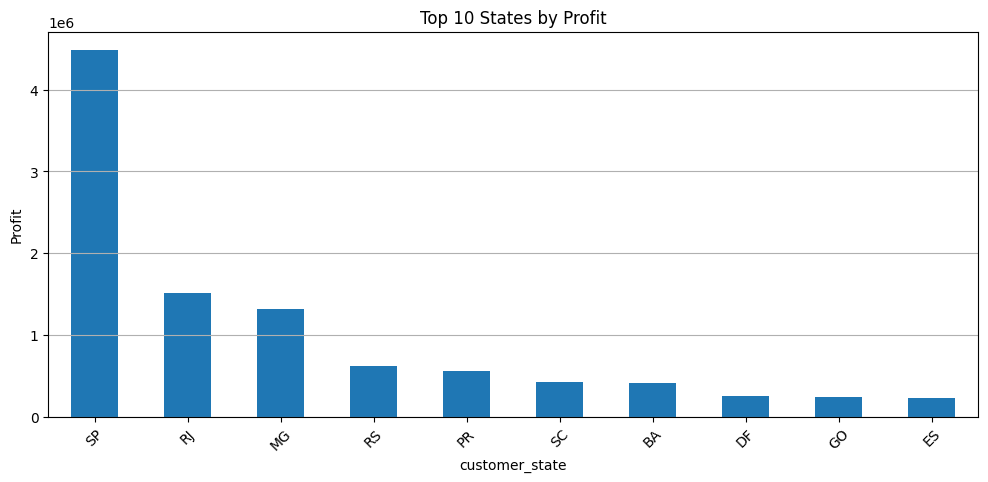

In [83]:
top_states = profit_by_state.head(10)

plt.figure(figsize=(12,5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [84]:
profit_df['profit'].describe()

count    112650.000000
mean        100.663419
std         177.670283
min        -140.530000
25%          24.520000
50%          56.290000
75%         111.830000
max        6540.690000
Name: profit, dtype: float64

In [85]:
profit_df[profit_df['profit'] < 0].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,profit
58,0025081dcf9330f9a5052ae82c6ce396,1,4e3f399366b0047a572b6682f9bb166e,5f3ae9136c875522250f8184f253413a,2018-04-02 16:35:20,14.95,18.23,livros_tecnicos,28.0,1313.0,1.0,300.0,23.0,2.0,16.0,-3.28
80,002f98c0f7efd42638ed6100ca699b42,1,d41dc2f2979f52d75d78714b378d4068,7299e27ed73d2ad986de7f7c77d919fa,2017-08-10 09:30:15,8.99,32.57,consoles_games,44.0,228.0,1.0,450.0,30.0,7.0,25.0,-23.58
110,003edccf16bc5ec447f592913b3df2b4,1,500870614ddcf5bd84f7d26861026c8a,ef506c96320abeedfb894c34db06f478,2018-07-12 10:15:21,14.00,50.85,telefonia,58.0,434.0,3.0,217.0,18.0,4.0,13.0,-36.85
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96,NaN,NaN,NaN,NaN,700.0,35.0,14.0,11.0,-3.36
156,00602f25bffa1dcfb71e202fbf9824fb,1,32a8448d1612773bcfd0c5a8dd235e4e,86ccac0b835037332a596a33b6949ee1,2017-11-08 02:31:17,39.90,54.02,relogios_presentes,60.0,362.0,5.0,700.0,24.0,5.0,24.0,-14.12


In [86]:
rfm_df = orders.merge(payments, on='order_id', how='left')
rfm_df = rfm_df.merge(customers, on='customer_id', how='left')

In [88]:
rfm_df['order_purchase_timestamp'] = pd.to_datetime(rfm_df['order_purchase_timestamp'])

In [89]:
import datetime as dt

snapshot_date = rfm_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2018-10-18 17:30:18')

In [91]:
rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
})

In [92]:
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74
000161a058600d5901f007fab4c27140,459,1,67.41
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42
0002414f95344307404f0ace7a26f1d5,428,1,179.35
000379cdec625522490c315e70c7a9fb,199,1,107.01


In [93]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [94]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74,2,1,3,213
000161a058600d5901f007fab4c27140,459,1,67.41,1,1,2,112
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,1,1,4,114
0002414f95344307404f0ace7a26f1d5,428,1,179.35,2,1,4,214
000379cdec625522490c315e70c7a9fb,199,1,107.01,4,1,3,413


In [95]:
def segment_customer(row):
    if row['R_score'] in ['4','5'] and row['F_score'] in ['4','5']:
        return 'Loyal Customers'
    elif row['R_score'] in ['1','2']:
        return 'Churned Customers'
    elif row['M_score'] in ['4','5']:
        return 'High Value Customers'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Regular Customers    99441
Name: count, dtype: int64

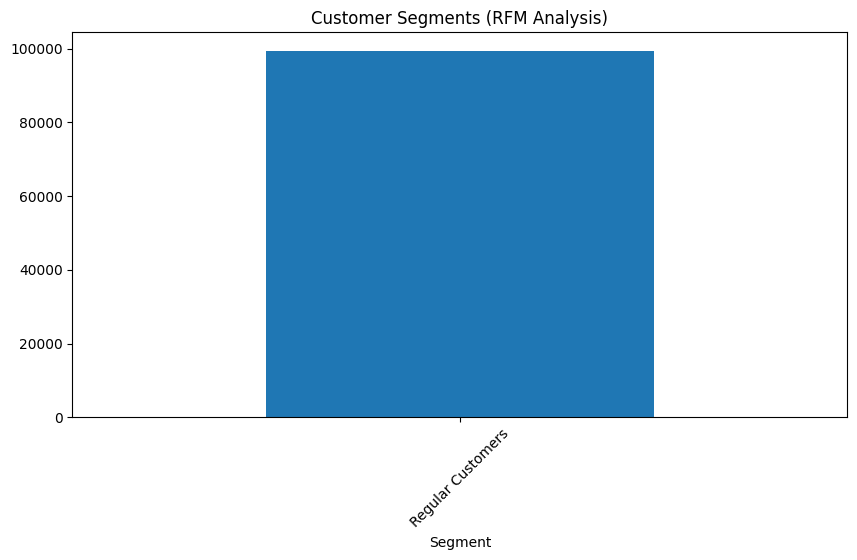

In [96]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Customer Segments (RFM Analysis)")
plt.xticks(rotation=45)
plt.show()

In [99]:
import pandas as pd

df = orders.merge(payments, on='order_id', how='left')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [100]:
monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum().reset_index()

monthly.columns = ['month', 'revenue']
monthly['month'] = monthly['month'].astype(str)

monthly.head()

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


In [102]:
monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month')

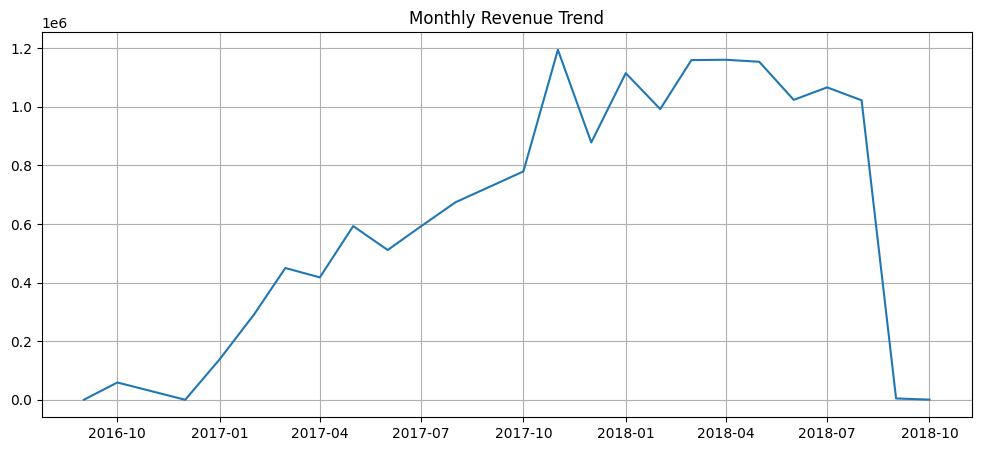

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly['month'], monthly['revenue'])
plt.title("Monthly Revenue Trend")
plt.grid()
plt.show()

In [105]:
monthly['MA_3'] = monthly['revenue'].rolling(window=3).mean()
monthly['MA_6'] = monthly['revenue'].rolling(window=6).mean()

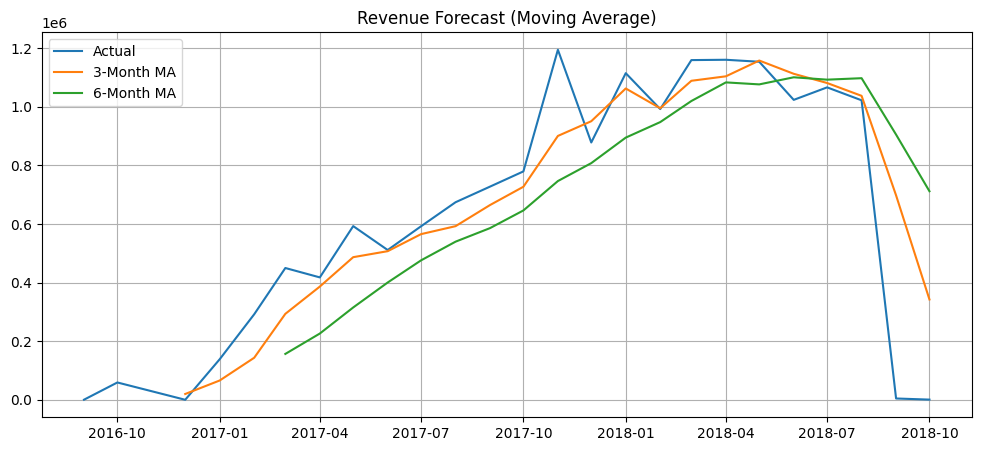

In [106]:
plt.figure(figsize=(12,5))

plt.plot(monthly['month'], monthly['revenue'], label='Actual')
plt.plot(monthly['month'], monthly['MA_3'], label='3-Month MA')
plt.plot(monthly['month'], monthly['MA_6'], label='6-Month MA')

plt.title("Revenue Forecast (Moving Average)")
plt.legend()
plt.grid()
plt.show()

In [107]:
future_forecast = monthly['MA_3'].iloc[-1]
future_forecast

np.float64(342484.8433333333)